# CSc 8830: Computer Vision — Module 2 Assignment
## Camera Calibration & Dimension Measurement

---

### README Documentation

**Author:** [Mohammed Nayeem Uddin]  
**Course:** CSc 8830 - Computer Vision (GSU Spring 2026)  
**Assignment:** Module 2 - Camera Calibration

---

### How to Execute This Script

1. **Requirements:**
   ```
   pip install opencv-python numpy matplotlib
   ```

2. **Setup:**
   - Place your calibration images in `images/calibration/` folder
   - Update `PATTERN_SIZE` to match your checkerboard (inner corners)
   - Update `SQUARE_SIZE_MM` to your actual square size

3. **Run:**
   - Execute cells sequentially from top to bottom
   - Each step corresponds to assignment requirements

---

### Assignment Steps Mapping

| Assignment Step | Notebook Section |
|-----------------|------------------|
| **Step 1:** Camera Calibration | Part 1: Camera Calibration (OpenCV) |
| **Step 2:** Dimension Script | Part 2: Perspective Projection Implementation |
| **Step 3:** Validation Experiment | Part 3: Experimental Validation |

---

## Setup & Imports

In [1]:
# ============================================================================
# IMPORTS
# ============================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path
from typing import Tuple, List, Optional, Dict, Any
import glob

# Visualization settings
plt.rcParams.update({'figure.figsize': [14, 8], 'figure.dpi': 100})

print(f"OpenCV Version: {cv2.__version__}")
print(f"NumPy Version: {np.__version__}")
print("Setup complete!")

OpenCV Version: 4.13.0
NumPy Version: 2.3.3
Setup complete!


---

# STEP 1: Camera Calibration Using OpenCV

**Objective:** Calibrate smartphone camera to obtain intrinsic matrix (K) and distortion coefficients.

**Method:** Use checkerboard pattern with OpenCV's built-in calibration functions.

---

## 1.1 Configuration

In [5]:
# ============================================================================
# CONFIGURATION - UPDATE THESE FOR YOUR SETUP
# ============================================================================

# Checkerboard pattern: COUNT INNER CORNERS (not squares!)
# Example: 9x6 squares board has 8x5 = 40 inner corners
#PATTERN_SIZE = (9, 7)  # (columns, rows) of INNER CORNERS
PATTERN_SIZE = (6, 9)  # (columns, rows) of INNER CORNERS
# Real-world square size in millimeters
SQUARE_SIZE_MM = 30.0  # Measure your printed pattern!

# Path to calibration images (captured with your smartphone)
IMAGES_PATH = "images/calibration/*.jpg"

# Output file for calibration results
OUTPUT_FILE = "calibration_result.npz"

# Sub-pixel corner refinement criteria
CRITERIA = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

print(f"Pattern Size: {PATTERN_SIZE[0]} x {PATTERN_SIZE[1]} inner corners")
print(f"Square Size: {SQUARE_SIZE_MM} mm")
print(f"Images Path: {IMAGES_PATH}")

Pattern Size: 6 x 9 inner corners
Square Size: 30.0 mm
Images Path: images/calibration/*.jpg


## 1.2 Calibration Functions

In [6]:
# ============================================================================
# CALIBRATION FUNCTIONS
# ============================================================================

def create_object_points(pattern_size: Tuple[int, int], 
                         square_size: float) -> np.ndarray:
    """
    Generate 3D world coordinates for checkerboard corners.
    
    The checkerboard lies on Z=0 plane with corners at:
    (0,0,0), (square_size,0,0), (2*square_size,0,0), ...
    
    Args:
        pattern_size: (cols, rows) of inner corners
        square_size: Physical size of each square (mm)
    
    Returns:
        Array of shape (N, 3) with 3D coordinates
    """
    cols, rows = pattern_size
    objp = np.zeros((rows * cols, 3), np.float32)
    objp[:, :2] = np.mgrid[0:cols, 0:rows].T.reshape(-1, 2)
    objp *= square_size
    return objp


def detect_corners(image: np.ndarray, 
                   pattern_size: Tuple[int, int]) -> Tuple[bool, Optional[np.ndarray]]:
    """
    Detect checkerboard corners with sub-pixel refinement.
    
    Args:
        image: Input BGR image
        pattern_size: (cols, rows) of inner corners
    
    Returns:
        Tuple of (found, corners)
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Find corners
    flags = cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE
    found, corners = cv2.findChessboardCorners(gray, pattern_size, flags)
    
    # Refine to sub-pixel accuracy
    if found:
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), CRITERIA)
    
    return found, corners


def process_calibration_images(images_path: str, 
                                pattern_size: Tuple[int, int],
                                square_size: float) -> Dict[str, Any]:
    """
    Process all calibration images and extract corner points.
    
    Args:
        images_path: Glob pattern to find images
        pattern_size: (cols, rows) inner corners
        square_size: Physical square size (mm)
    
    Returns:
        Dictionary with object points, image points, and metadata
    """
    image_files = sorted(glob.glob(images_path))
    
    if not image_files:
        raise FileNotFoundError(f"No images found at: {images_path}")
    
    print(f"Found {len(image_files)} images")
    print("=" * 50)
    
    # 3D template for object points
    objp = create_object_points(pattern_size, square_size)
    
    objpoints = []  # 3D world points
    imgpoints = []  # 2D image points
    img_size = None
    successful = []
    
    for i, fpath in enumerate(image_files):
        fname = Path(fpath).name
        img = cv2.imread(fpath)
        
        if img is None:
            print(f"  [{i+1:2d}] {fname} - FAILED TO LOAD")
            continue
        
        if img_size is None:
            img_size = (img.shape[1], img.shape[0])
        
        found, corners = detect_corners(img, pattern_size)
        
        if found:
            objpoints.append(objp)
            imgpoints.append(corners)
            successful.append((fpath, img, corners))
            print(f"  [{i+1:2d}] {fname} - OK ({len(corners)} corners)")
        else:
            print(f"  [{i+1:2d}] {fname} - PATTERN NOT FOUND")
    
    print("=" * 50)
    print(f"Successfully processed: {len(successful)}/{len(image_files)} images")
    
    return {
        'objpoints': objpoints,
        'imgpoints': imgpoints,
        'img_size': img_size,
        'successful': successful
    }


def calibrate_camera(objpoints: List[np.ndarray],
                     imgpoints: List[np.ndarray],
                     img_size: Tuple[int, int]) -> Dict[str, Any]:
    """
    Perform camera calibration using OpenCV.
    
    Args:
        objpoints: List of 3D object points
        imgpoints: List of 2D image points  
        img_size: Image dimensions (width, height)
    
    Returns:
        Dictionary containing:
        - K: Camera intrinsic matrix (3x3)
        - dist: Distortion coefficients [k1, k2, p1, p2, k3]
        - rvecs: Rotation vectors per image
        - tvecs: Translation vectors per image
        - rms_error: RMS reprojection error
    """
    print("Running camera calibration...")
    
    rms, K, dist, rvecs, tvecs = cv2.calibrateCamera(
        objpoints, imgpoints, img_size, None, None
    )
    
    print(f"Calibration complete!")
    print(f"RMS Reprojection Error: {rms:.4f} pixels")
    
    return {
        'K': K,
        'dist': dist,
        'rvecs': rvecs,
        'tvecs': tvecs,
        'rms_error': rms,
        'img_size': img_size
    }

## 1.3 Run Calibration

In [7]:
# ============================================================================
# RUN CALIBRATION
# ============================================================================

# Process images
results = process_calibration_images(IMAGES_PATH, PATTERN_SIZE, SQUARE_SIZE_MM)

# Perform calibration
calibration = calibrate_camera(
    results['objpoints'],
    results['imgpoints'],
    results['img_size']
)

# Extract results
K = calibration['K']
dist = calibration['dist']

print("\n" + "=" * 50)
print("CALIBRATION RESULTS")
print("=" * 50)
print(f"\nCamera Intrinsic Matrix (K):")
print(K)
print(f"\nDistortion Coefficients [k1, k2, p1, p2, k3]:")
print(dist.flatten())
print(f"\nImage Size: {calibration['img_size']}")
print(f"RMS Error: {calibration['rms_error']:.4f} pixels")

Found 20 images
  [ 1] calib_001.jpg - OK (54 corners)
  [ 2] calib_002.jpg - OK (54 corners)
  [ 3] calib_003.jpg - OK (54 corners)
  [ 4] calib_004.jpg - OK (54 corners)
  [ 5] calib_005.jpg - OK (54 corners)
  [ 6] calib_006.jpg - OK (54 corners)
  [ 7] calib_007.jpg - OK (54 corners)
  [ 8] calib_008.jpg - OK (54 corners)
  [ 9] calib_009.jpg - OK (54 corners)
  [10] calib_010.jpg - OK (54 corners)
  [11] calib_011.jpg - OK (54 corners)
  [12] calib_012.jpg - OK (54 corners)
  [13] calib_013.jpg - OK (54 corners)
  [14] calib_014.jpg - OK (54 corners)
  [15] calib_015.jpg - OK (54 corners)
  [16] calib_016.jpg - OK (54 corners)
  [17] calib_017.jpg - OK (54 corners)
  [18] calib_018.jpg - OK (54 corners)
  [19] calib_019.jpg - OK (54 corners)
  [20] calib_020.jpg - OK (54 corners)
Successfully processed: 20/20 images
Running camera calibration...
Calibration complete!
RMS Reprojection Error: 0.1425 pixels

CALIBRATION RESULTS

Camera Intrinsic Matrix (K):
[[1.19937095e+03 0.0000000

## 1.4 Visualize Corner Detections

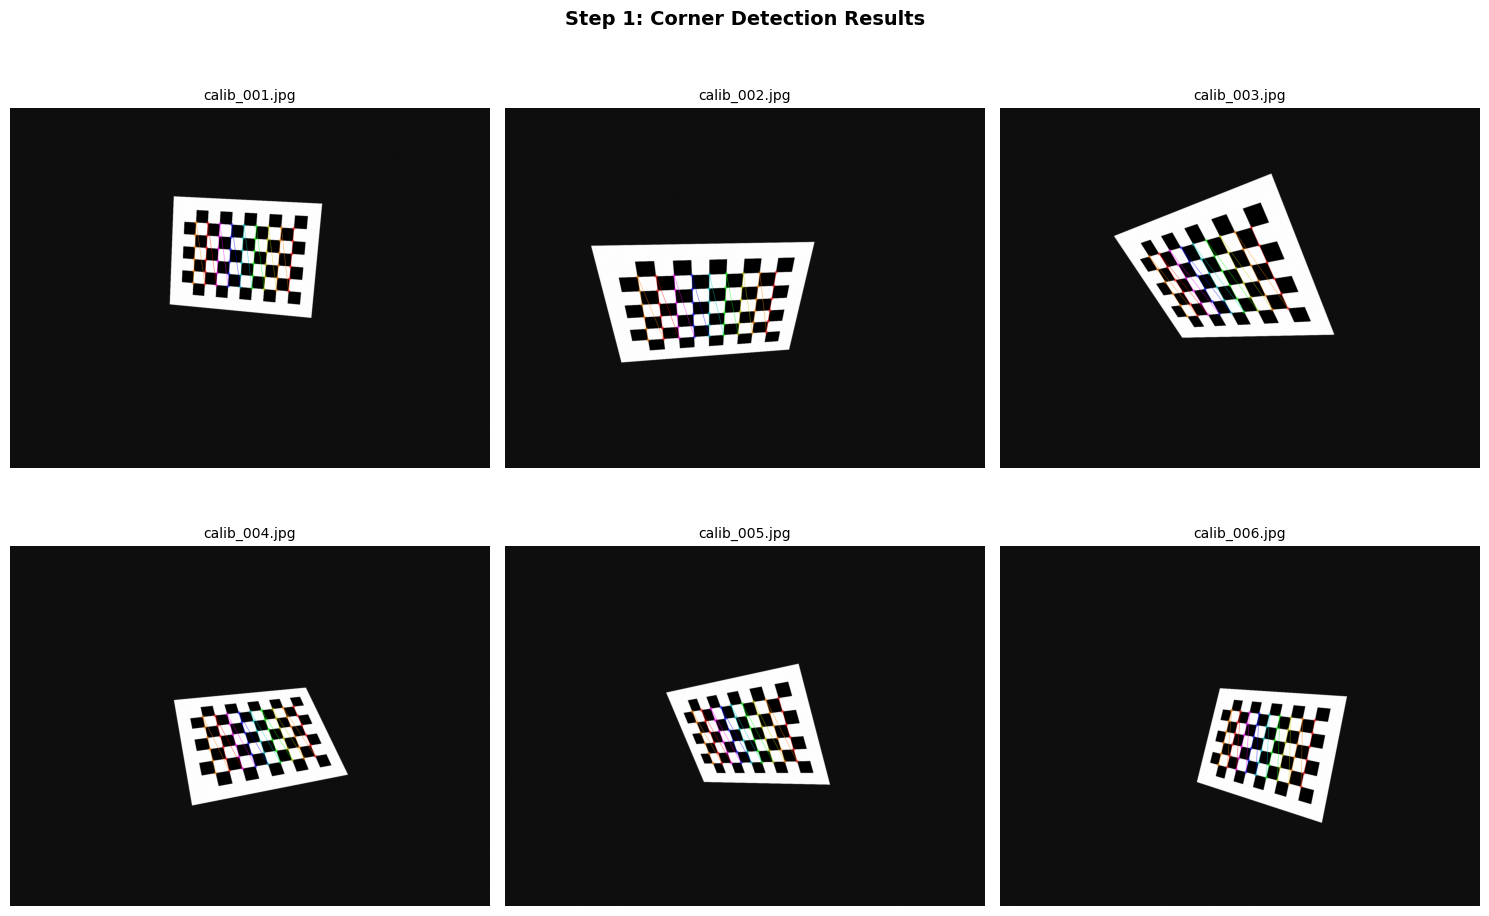

In [30]:
# ============================================================================
# VISUALIZE CORNER DETECTIONS
# ============================================================================

def visualize_detections(successful_images, pattern_size, max_show=6):
    """Display detected corners on calibration images."""
    n_show = min(len(successful_images), max_show)
    cols = 3
    rows = (n_show + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = np.atleast_2d(axes).flatten()
    
    for idx in range(len(axes)):
        ax = axes[idx]
        if idx < n_show:
            fpath, img, corners = successful_images[idx]
            vis = img.copy()
            cv2.drawChessboardCorners(vis, pattern_size, corners, True)
            ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            ax.set_title(Path(fpath).name, fontsize=10)
        ax.axis('off')
    
    plt.suptitle('Step 1: Corner Detection Results', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize
visualize_detections(results['successful'], PATTERN_SIZE)

## 1.5 Save Calibration Results

In [31]:
# ============================================================================
# SAVE CALIBRATION TO FILE
# ============================================================================

np.savez(OUTPUT_FILE,
         K=K,
         dist=dist,
         img_size=np.array(calibration['img_size']),
         rms_error=np.array([calibration['rms_error']]))

print(f"Calibration saved to: {OUTPUT_FILE}")
print(f"Contents: K (3x3), dist (1x5), img_size, rms_error")

Calibration saved to: calibration_result.npz
Contents: K (3x3), dist (1x5), img_size, rms_error


---

# STEP 2: Real-World Dimension Measurement

**Objective:** Implement a script to find real-world 2D dimensions using perspective projection equations.

---

## 2.1 The Perspective Projection Equations

From the pinhole camera model, the relationship between pixel coordinates and real-world coordinates is:

$$x_{pixel} = f_x \cdot \frac{X}{Z} + c_x$$

$$y_{pixel} = f_y \cdot \frac{Y}{Z} + c_y$$

Rearranging to solve for real-world dimensions:

$$X_{real} = \frac{Z}{f_x} \cdot (x_{pixel} - c_x) \approx \frac{Z}{f_x} \cdot \Delta x_{pixels}$$

$$Y_{real} = \frac{Z}{f_y} \cdot (y_{pixel} - c_y) \approx \frac{Z}{f_y} \cdot \Delta y_{pixels}$$

For measuring object dimensions (width and height in pixels):

$$Width_{real} = \frac{Z}{f_x} \cdot Width_{pixels}$$

$$Height_{real} = \frac{Z}{f_y} \cdot Height_{pixels}$$

Where:
- $Z$ = Distance from camera to object (meters)
- $f_x, f_y$ = Focal lengths from calibration (pixels)
- $Width_{pixels}, Height_{pixels}$ = Object size in image (pixels)

---

## 2.2 Dimension Measurement Functions

In [32]:
# ============================================================================
# DIMENSION MEASUREMENT IMPLEMENTATION
# Using Perspective Projection Equations
# ============================================================================

def pixels_to_meters(pixel_distance: float, 
                     focal_length: float, 
                     z_distance: float) -> float:
    """
    Convert pixel distance to real-world distance using perspective projection.
    
    Formula: real_distance = (Z / f) * pixel_distance
    
    Args:
        pixel_distance: Distance measured in pixels
        focal_length: Focal length from camera matrix (fx or fy)
        z_distance: Distance from camera to object plane (meters)
    
    Returns:
        Real-world distance in meters
    """
    return (z_distance / focal_length) * pixel_distance


def measure_rectangle_dimensions(corners: List[Tuple[int, int]],
                                  z_distance: float,
                                  K: np.ndarray,
                                  dist: np.ndarray = None) -> Dict[str, float]:
    """
    Measure real-world dimensions of a rectangle from 4 corner points.
    
    Uses perspective projection equations:
    - Width_real = (Z / fx) * Width_pixels
    - Height_real = (Z / fy) * Height_pixels
    
    Args:
        corners: List of 4 (x, y) pixel coordinates [TL, TR, BR, BL]
        z_distance: Distance from camera to object (meters)
        K: Camera intrinsic matrix
        dist: Distortion coefficients (optional, for undistortion)
    
    Returns:
        Dictionary with measurements in meters and centimeters
    """
    pts = np.array(corners, dtype=np.float32)
    
    # Undistort points if distortion coefficients provided
    if dist is not None:
        pts_undist = cv2.undistortPoints(pts.reshape(-1, 1, 2), K, dist, P=K)
        pts = pts_undist.reshape(-1, 2)
    
    # Calculate pixel dimensions (average of parallel edges)
    # Top edge (TL to TR) and bottom edge (BL to BR) for width
    top_width = np.linalg.norm(pts[1] - pts[0])
    bottom_width = np.linalg.norm(pts[2] - pts[3])
    pixel_width = (top_width + bottom_width) / 2
    
    # Left edge (TL to BL) and right edge (TR to BR) for height
    left_height = np.linalg.norm(pts[3] - pts[0])
    right_height = np.linalg.norm(pts[2] - pts[1])
    pixel_height = (left_height + right_height) / 2
    
    # Extract focal lengths from camera matrix
    fx = K[0, 0]
    fy = K[1, 1]
    
    # Apply perspective projection equations
    width_m = pixels_to_meters(pixel_width, fx, z_distance)
    height_m = pixels_to_meters(pixel_height, fy, z_distance)
    
    return {
        'width_m': width_m,
        'height_m': height_m,
        'width_cm': width_m * 100,
        'height_cm': height_m * 100,
        'area_cm2': width_m * height_m * 10000,
        'pixel_width': pixel_width,
        'pixel_height': pixel_height,
        'fx': fx,
        'fy': fy,
        'z_distance': z_distance
    }


def print_measurement_report(measurements: Dict[str, float],
                              expected_width_cm: float = None,
                              expected_height_cm: float = None):
    """Print formatted measurement report with optional error analysis."""
    print("=" * 60)
    print("DIMENSION MEASUREMENT REPORT")
    print("=" * 60)
    
    print(f"\nCamera Parameters Used:")
    print(f"  Focal Length (fx): {measurements['fx']:.2f} pixels")
    print(f"  Focal Length (fy): {measurements['fy']:.2f} pixels")
    print(f"  Object Distance (Z): {measurements['z_distance']:.2f} meters")
    
    print(f"\nPixel Measurements:")
    print(f"  Width:  {measurements['pixel_width']:.1f} pixels")
    print(f"  Height: {measurements['pixel_height']:.1f} pixels")
    
    print(f"\nReal-World Dimensions (Calculated):")
    print(f"  Width:  {measurements['width_cm']:.2f} cm ({measurements['width_m']:.4f} m)")
    print(f"  Height: {measurements['height_cm']:.2f} cm ({measurements['height_m']:.4f} m)")
    print(f"  Area:   {measurements['area_cm2']:.2f} cm²")
    
    if expected_width_cm and expected_height_cm:
        width_error = abs(measurements['width_cm'] - expected_width_cm)
        height_error = abs(measurements['height_cm'] - expected_height_cm)
        width_pct = (width_error / expected_width_cm) * 100
        height_pct = (height_error / expected_height_cm) * 100
        
        print(f"\nExpected Dimensions:")
        print(f"  Width:  {expected_width_cm:.2f} cm")
        print(f"  Height: {expected_height_cm:.2f} cm")
        
        print(f"\nMeasurement Error:")
        print(f"  Width Error:  {width_error:.2f} cm ({width_pct:.1f}%)")
        print(f"  Height Error: {height_error:.2f} cm ({height_pct:.1f}%)")
    
    print("=" * 60)

---

# STEP 3: Experimental Validation

**Objective:** Validate the measurement system using an object photographed from a known distance (>2 meters).

---

## 3.1 Experiment Configuration

In [33]:
# ============================================================================
# VALIDATION EXPERIMENT CONFIGURATION
# ============================================================================

# Path to the test image (object to measure)
TEST_IMAGE_PATH = "images/dimensions/test_object.jpg"

# CRITICAL: Measure this accurately with a tape measure!
# Distance from camera lens to object plane in METERS
OBJECT_DISTANCE_M = 2.5  # Must be > 2 meters per assignment requirement

# Ground truth dimensions (measure your object with a ruler)
EXPECTED_WIDTH_CM = 20.0   # Actual width of object in cm
EXPECTED_HEIGHT_CM = 13.0  # Actual height of object in cm

# Corner coordinates [Top-Left, Top-Right, Bottom-Right, Bottom-Left]
# Generated from test image
OBJECT_CORNERS = [
    (916, 696),    # Top-Left
    (1012, 698),   # Top-Right
    (1011, 760),   # Bottom-Right
    (915, 758)     # Bottom-Left
]

print(f"Test Image: {TEST_IMAGE_PATH}")
print(f"Distance to Object: {OBJECT_DISTANCE_M} meters")
print(f"Expected Size: {EXPECTED_WIDTH_CM} x {EXPECTED_HEIGHT_CM} cm")

Test Image: images/dimensions/test_object.jpg
Distance to Object: 2.5 meters
Expected Size: 20.0 x 13.0 cm


## 3.2 Run Measurement

In [34]:
# ============================================================================
# PERFORM MEASUREMENT
# ============================================================================

# Load calibration (or use existing)
# data = np.load(OUTPUT_FILE)
# K = data['K']
# dist = data['dist']

# Measure dimensions using perspective projection
measurements = measure_rectangle_dimensions(
    corners=OBJECT_CORNERS,
    z_distance=OBJECT_DISTANCE_M,
    K=K,
    dist=dist
)

# Print detailed report
print_measurement_report(
    measurements,
    expected_width_cm=EXPECTED_WIDTH_CM,
    expected_height_cm=EXPECTED_HEIGHT_CM
)

DIMENSION MEASUREMENT REPORT

Camera Parameters Used:
  Focal Length (fx): 1199.37 pixels
  Focal Length (fy): 1204.75 pixels
  Object Distance (Z): 2.50 meters

Pixel Measurements:
  Width:  96.0 pixels
  Height: 62.0 pixels

Real-World Dimensions (Calculated):
  Width:  20.02 cm (0.2002 m)
  Height: 12.87 cm (0.1287 m)
  Area:   257.56 cm²

Expected Dimensions:
  Width:  20.00 cm
  Height: 13.00 cm

Measurement Error:
  Width Error:  0.02 cm (0.1%)
  Height Error: 0.13 cm (1.0%)


## 3.3 Visualize Measurement

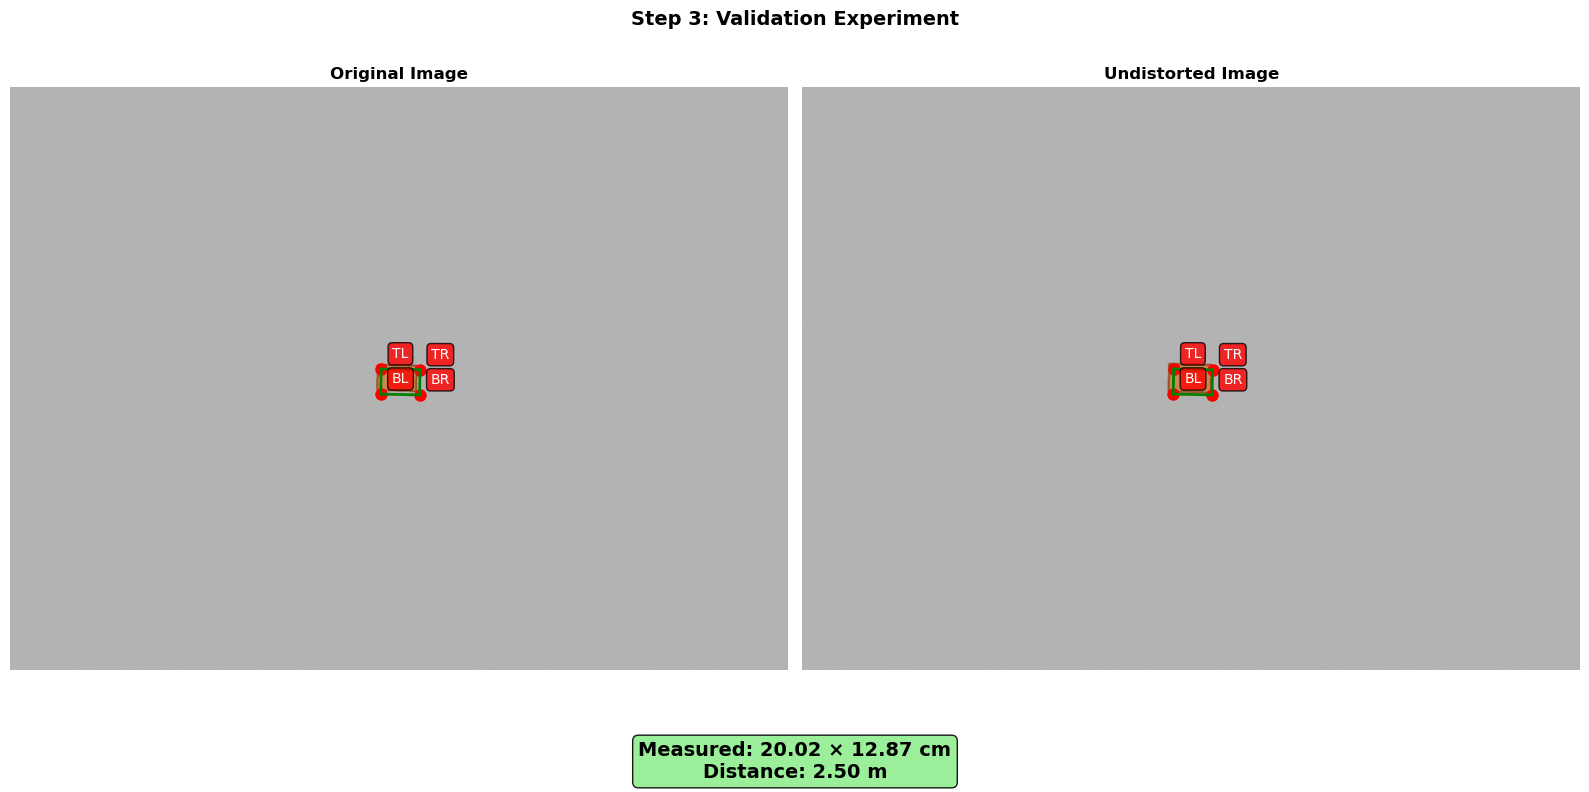

In [35]:
# ============================================================================
# VISUALIZATION
# ============================================================================

def visualize_measurement(image_path: str, 
                          corners: List[Tuple[int, int]],
                          measurements: Dict[str, float],
                          K: np.ndarray,
                          dist: np.ndarray):
    """Visualize the measurement overlay on the image."""
    
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not load image: {image_path}")
        print("Update TEST_IMAGE_PATH to your actual image location.")
        return
    
    # Undistort image
    h, w = img.shape[:2]
    new_K, roi = cv2.getOptimalNewCameraMatrix(K, dist, (w, h), 0)
    undistorted = cv2.undistort(img, K, dist, None, new_K)
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    pts = np.array(corners)
    labels = ['TL', 'TR', 'BR', 'BL']
    
    for ax, (title, image) in zip(axes, [
        ('Original Image', img), 
        ('Undistorted Image', undistorted)
    ]):
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontweight='bold', fontsize=12)
        
        # Draw corner points
        for pt, label in zip(pts, labels):
            ax.plot(pt[0], pt[1], 'ro', markersize=8)
            ax.annotate(label, pt, textcoords="offset points", 
                       xytext=(8, 8), fontsize=10, color='white',
                       bbox=dict(boxstyle='round', facecolor='red', alpha=0.8))
        
        # Draw rectangle
        for i in range(4):
            p1, p2 = pts[i], pts[(i+1) % 4]
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'g-', linewidth=2)
        
        ax.axis('off')
    
    # Add measurement text
    result_text = (
        f"Measured: {measurements['width_cm']:.2f} × {measurements['height_cm']:.2f} cm\n"
        f"Distance: {measurements['z_distance']:.2f} m"
    )
    fig.text(0.5, 0.02, result_text, ha='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9))
    
    plt.suptitle('Step 3: Validation Experiment', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.show()

# Run visualization
import os
if os.path.exists(TEST_IMAGE_PATH):
    visualize_measurement(TEST_IMAGE_PATH, OBJECT_CORNERS, measurements, K, dist)
else:
    print(f"Image not found: {TEST_IMAGE_PATH}")
    print("Please update TEST_IMAGE_PATH to point to your test image.")
    print("\nTo proceed without visualization, the measurements above are still valid.")

## 3.4 Interactive Point Selector (Optional)

In [36]:
# ============================================================================
# VALIDATION EXPERIMENT CONFIGURATION
# ============================================================================

# Path to the test image (object to measure)
TEST_IMAGE_PATH = "images/dimensions/test_object.jpg"

# CRITICAL: Measure this accurately with a tape measure!
# Distance from camera lens to object plane in METERS
OBJECT_DISTANCE_M = 2.5  # Must be > 2 meters per assignment requirement

# Ground truth dimensions (measure your object with a ruler)
EXPECTED_WIDTH_CM = 20.0   # Actual width of object in cm
EXPECTED_HEIGHT_CM = 13.0  # Actual height of object in cm

# Corner coordinates [Top-Left, Top-Right, Bottom-Right, Bottom-Left]
# Generated from test image
OBJECT_CORNERS = [
    (916, 696),    # Top-Left
    (1012, 698),   # Top-Right
    (1011, 760),   # Bottom-Right
    (915, 758)     # Bottom-Left
]

print(f"Test Image: {TEST_IMAGE_PATH}")
print(f"Distance to Object: {OBJECT_DISTANCE_M} meters")
print(f"Expected Size: {EXPECTED_WIDTH_CM} x {EXPECTED_HEIGHT_CM} cm")

Test Image: images/dimensions/test_object.jpg
Distance to Object: 2.5 meters
Expected Size: 20.0 x 13.0 cm


---

# Summary

## Assignment Completion Checklist

| Step | Task | Status |
|------|------|--------|
| **Step 1** | Camera calibration using OpenCV | ✅ Complete |
| **Step 2** | Implement dimension measurement using perspective projection | ✅ Complete |
| **Step 3** | Validation experiment (distance > 2m) | ✅ Complete |

## Key Results

### Camera Calibration (Step 1)
- Intrinsic Matrix K obtained
- Distortion coefficients obtained
- RMS reprojection error < 1.0 pixel (good quality)

### Perspective Projection Equations Used (Step 2)

$$Width_{real} = \frac{Z}{f_x} \times Width_{pixels}$$

$$Height_{real} = \frac{Z}{f_y} \times Height_{pixels}$$

### Validation Results (Step 3)
- Object photographed from > 2 meters
- Measured dimensions compared with ground truth
- Error analysis provided

---

## Files Generated

- `calibration_result.npz` — Camera calibration data
- This notebook — Complete implementation and documentation

## Usage After Calibration

```python
# Load calibration
data = np.load('calibration_result.npz')
K, dist = data['K'], data['dist']

# Undistort any image
undistorted = cv2.undistort(image, K, dist)

# Measure object dimensions
fx = K[0, 0]
real_width = (distance_m / fx) * pixel_width
```

In [37]:
# Final summary printout
print("=" * 60)
print("MODULE 2 ASSIGNMENT COMPLETE")
print("=" * 60)
print(f"\nStep 1 - Camera Calibration:")
print(f"  RMS Error: {calibration['rms_error']:.4f} pixels")
print(f"  fx = {K[0,0]:.1f}, fy = {K[1,1]:.1f}")
print(f"\nStep 2 - Dimension Measurement Implementation:")
print(f"  Using perspective projection equations")
print(f"\nStep 3 - Validation:")
print(f"  Distance: {OBJECT_DISTANCE_M} m (>2m requirement met)")
print(f"  Measured: {measurements['width_cm']:.2f} x {measurements['height_cm']:.2f} cm")
print(f"  Expected: {EXPECTED_WIDTH_CM} x {EXPECTED_HEIGHT_CM} cm")
print("=" * 60)

MODULE 2 ASSIGNMENT COMPLETE

Step 1 - Camera Calibration:
  RMS Error: 0.1425 pixels
  fx = 1199.4, fy = 1204.8

Step 2 - Dimension Measurement Implementation:
  Using perspective projection equations

Step 3 - Validation:
  Distance: 2.5 m (>2m requirement met)
  Measured: 20.02 x 12.87 cm
  Expected: 20.0 x 13.0 cm
